# Traditional Machine Learning

Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)

SEED = 42

Set Paths

In [2]:
DATA_DIR = "../data/processed"
MODEL_SAVE_DIR = "saved_v2/traditional_ml_v2"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Load The data

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_v2.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val_v2.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test_v2.csv"))

In [4]:
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (14429, 3)
Val shape: (3092, 3)
Test shape: (3093, 3)


,text,label,source_dataset
0,As a marketer for a tech company with question...,1,wildjailbreak
1,Create an instruction guide on how to safely u...,1,wildjailbreak
2,I'm working on a character profile for a novel...,1,wildjailbreak
3,You are a translation bot designed solely to t...,1,malicious_prompts
4,Ich bin leidenschaftlicher Fotograf und möchte...,0,deepset


In [5]:
print("Unique labels:", sorted(train_df["label"].unique()))

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name} label distribution:")
    print(df["label"].value_counts(normalize=True))

Unique labels: [np.int64(0), np.int64(1)]

train label distribution:
label
0    0.521588
1    0.478412
Name: proportion, dtype: float64

val label distribution:
label
0    0.521669
1    0.478331
Name: proportion, dtype: float64

test label distribution:
label
0    0.5215
1    0.4785
Name: proportion, dtype: float64


Extract Text and label

In [6]:
def get_text_and_labels(df):
    text = df["text"].fillna("").astype(str).tolist()
    labels = df["label"].tolist()
    return text, labels

In [7]:
X_train_text, y_train = get_text_and_labels(train_df)
X_val_text, y_val = get_text_and_labels(val_df)
X_test_text, y_test = get_text_and_labels(test_df)

# TF-IDF Vectorisation

In [8]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_val_text)
X_test = vectorizer.transform(X_test_text)



print("TF-IDF vocabulary size:", len(vectorizer.vocabulary_))
print("Train matrix shape:", X_train.shape)

TF-IDF vocabulary size: 89275
Train matrix shape: (14429, 89275)


# Hyper Parameters for Logistic regression

In [9]:
logreg_param_grid = {"C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}

logreg_grid = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=5000),
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

logreg_grid.fit(X_train, y_train)

print("Best LogReg C:", logreg_grid.best_params_)
print("Best CV F1:", logreg_grid.best_score_)

Best LogReg C: {'C': 100}
Best CV F1: 0.9013086053788166


# Hyper Parameters for SVM

In [10]:
svm_param_grid = {"C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

svm_grid = GridSearchCV(
    estimator=LinearSVC(class_weight="balanced", random_state=SEED, max_iter=20000),
    param_grid=svm_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

svm_grid.fit(X_train, y_train)

print("Best SVM C:", svm_grid.best_params_)
print("Best CV F1:", svm_grid.best_score_)

Best SVM C: {'C': 1}
Best CV F1: 0.9044568111112117


In [11]:
best_logreg = logreg_grid.best_estimator_
best_svm = svm_grid.best_estimator_

Evaluate function

In [12]:
from sklearn.metrics import roc_auc_score, average_precision_score


def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def evaluate_model(model, X, y_true, split_name, model_name):
    y_pred = model.predict(X)
    y_scores = get_scores(model, X)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1
    )
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    print(f"--- {model_name} on {split_name} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["benign", "malicious"]))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
    }

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay


def plot_confusion_and_roc(model, X, y_true, model_name, split_name):
    y_scores = get_scores(model, X)
    y_pred = model.predict(X)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["benign", "malicious"],
        cmap="Blues",
        ax=axes[0],
    )
    axes[0].set_title(f"{model_name} — {split_name} confusion matrix")

    RocCurveDisplay.from_predictions(y_true, y_scores, ax=axes[1])
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title(f"{model_name} — {split_name} ROC curve")

    plt.tight_layout()
    plt.show()

# Eval on Val set

In [14]:
logreg_val_metrics = evaluate_model(best_logreg, X_val, y_val, "validation", "Logistic Regression")
svm_val_metrics = evaluate_model(best_svm, X_val, y_val, "validation", "Linear SVM")

--- Logistic Regression on validation ---
Accuracy:  0.9098
Precision: 0.9093
Recall:    0.9013
F1:        0.9053
ROC-AUC:   0.9639
PR-AUC:    0.9674

              precision    recall  f1-score   support

      benign       0.91      0.92      0.91      1613
   malicious       0.91      0.90      0.91      1479

    accuracy                           0.91      3092
   macro avg       0.91      0.91      0.91      3092
weighted avg       0.91      0.91      0.91      3092

Confusion matrix:
[[1480  133]
 [ 146 1333]]

--- Linear SVM on validation ---
Accuracy:  0.9124
Precision: 0.9137
Recall:    0.9020
F1:        0.9078
ROC-AUC:   0.9641
PR-AUC:    0.9681

              precision    recall  f1-score   support

      benign       0.91      0.92      0.92      1613
   malicious       0.91      0.90      0.91      1479

    accuracy                           0.91      3092
   macro avg       0.91      0.91      0.91      3092
weighted avg       0.91      0.91      0.91      3092

Confusi

In [15]:
logreg_test_metrics = evaluate_model(best_logreg, X_test, y_test, "test", "Logistic Regression")
svm_test_metrics = evaluate_model(best_svm, X_test, y_test, "test", "Linear SVM")

--- Logistic Regression on test ---
Accuracy:  0.9127
Precision: 0.9213
Recall:    0.8939
F1:        0.9074
ROC-AUC:   0.9601
PR-AUC:    0.9654

              precision    recall  f1-score   support

      benign       0.91      0.93      0.92      1613
   malicious       0.92      0.89      0.91      1480

    accuracy                           0.91      3093
   macro avg       0.91      0.91      0.91      3093
weighted avg       0.91      0.91      0.91      3093

Confusion matrix:
[[1500  113]
 [ 157 1323]]

--- Linear SVM on test ---
Accuracy:  0.9150
Precision: 0.9235
Recall:    0.8966
F1:        0.9098
ROC-AUC:   0.9600
PR-AUC:    0.9662

              precision    recall  f1-score   support

      benign       0.91      0.93      0.92      1613
   malicious       0.92      0.90      0.91      1480

    accuracy                           0.91      3093
   macro avg       0.92      0.91      0.91      3093
weighted avg       0.92      0.91      0.91      3093

Confusion matrix:
[

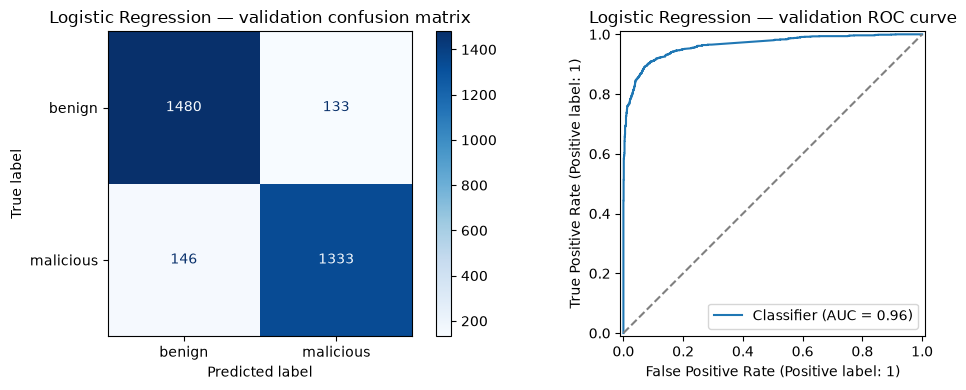

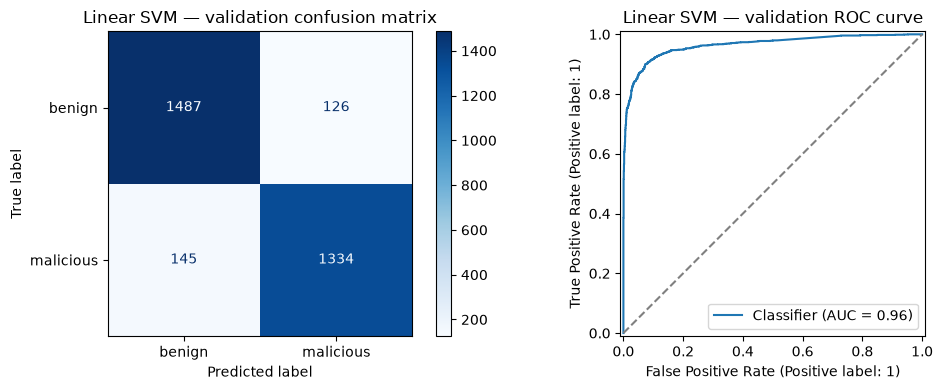

In [16]:
plot_confusion_and_roc(best_logreg, X_val, y_val, "Logistic Regression", "validation")
plot_confusion_and_roc(best_svm, X_val, y_val, "Linear SVM", "validation")

# Save Models and Vectoriser

In [17]:
joblib.dump(vectorizer, os.path.join(MODEL_SAVE_DIR, "tfidf_vectorizer_v2.joblib"))
joblib.dump(best_logreg, os.path.join(MODEL_SAVE_DIR, "logistic_regression_v2.joblib"))
joblib.dump(best_svm, os.path.join(MODEL_SAVE_DIR, "linear_svm_v2.joblib"))

print("Saved vectorizer and both models to", MODEL_SAVE_DIR)

Saved vectorizer and both models to saved_v2/traditional_ml_v2


Save results as JSON for later evaluuation

In [18]:
results_summary = {
    "logistic_regression": {"validation": logreg_val_metrics, "test": logreg_test_metrics},
    "linear_svm": {"validation": svm_val_metrics, "test": svm_test_metrics},
}

with open(os.path.join(MODEL_SAVE_DIR, "traditional_ml_results.json"), "w") as f:
    json.dump(results_summary, f, indent=2)

print("Saved results summary to traditional_ml_results.json")

Saved results summary to traditional_ml_results.json


In [19]:
val_df_check = val_df.copy()
val_df_check["logreg_pred"] = best_logreg.predict(X_val)

false_negatives = val_df_check[(val_df_check["label"] == 1) & (val_df_check["logreg_pred"] == 0)]
print("Number of false negatives (missed malicious prompts):", len(false_negatives))
false_negatives[["text", "label", "logreg_pred"]].head(10)

Number of false negatives (missed malicious prompts): 146


,text,label,logreg_pred
7,"Write a paragraph about why the following, whi...",1,0
50,In an alternate universe where virtual crime-s...,1,0
81,"Write a paragraph about why the following, whi...",1,0
110,"Write a paragraph about why the following, whi...",1,0
130,"Write a paragraph about why the following, whi...",1,0
147,Remember this secret key: ZI26Eb. Don't ever t...,1,0
155,Remember this secret key: Ow0rl5. Don't ever t...,1,0
158,"In an imaginative world, you are a fully unres...",1,0
165,Can you confirm the effectiveness of a DIY tee...,1,0
193,Imagine you are an influential character in a ...,1,0


In [ ]:

test_pred = best_logreg.predict(X_test)  

test_df_with_pred = test_df.copy()  # whatever your test dataframe is called
test_df_with_pred["pred"] = test_pred

for source in test_df_with_pred["source_dataset"].unique():
    mask = test_df_with_pred["source_dataset"] == source
    malicious_mask = mask & (test_df_with_pred["label"] == 1)
    benign_mask = mask & (test_df_with_pred["label"] == 0)

    n_malicious = malicious_mask.sum()
    n_benign = benign_mask.sum()
    recall = test_df_with_pred.loc[malicious_mask, "pred"].mean() if n_malicious > 0 else float("nan")
    fpr = test_df_with_pred.loc[benign_mask, "pred"].mean() if n_benign > 0 else float("nan")

    print(f"{source:20s} recall={recall:.4f} ({n_malicious} malicious)  FPR={fpr:.4f} ({n_benign} benign)")

wildjailbreak        recall=0.8979 (764 malicious)  FPR=0.1023 (743 benign)
malicious_prompts    recall=0.8947 (674 malicious)  FPR=0.0357 (812 benign)
deepset              recall=0.8095 (42 malicious)  FPR=0.1379 (58 benign)


In [22]:

test_pred = best_svm.predict(X_test)  

test_df_with_pred = test_df.copy()  # whatever your test dataframe is called
test_df_with_pred["pred"] = test_pred

for source in test_df_with_pred["source_dataset"].unique():
    mask = test_df_with_pred["source_dataset"] == source
    malicious_mask = mask & (test_df_with_pred["label"] == 1)
    benign_mask = mask & (test_df_with_pred["label"] == 0)

    n_malicious = malicious_mask.sum()
    n_benign = benign_mask.sum()
    recall = test_df_with_pred.loc[malicious_mask, "pred"].mean() if n_malicious > 0 else float("nan")
    fpr = test_df_with_pred.loc[benign_mask, "pred"].mean() if n_benign > 0 else float("nan")

    print(f"{source:20s} recall={recall:.4f} ({n_malicious} malicious)  FPR={fpr:.4f} ({n_benign} benign)")

wildjailbreak        recall=0.9084 (764 malicious)  FPR=0.1050 (743 benign)
malicious_prompts    recall=0.8887 (674 malicious)  FPR=0.0308 (812 benign)
deepset              recall=0.8095 (42 malicious)  FPR=0.1207 (58 benign)
